# How the ECB Responded to the 2021–2023 Inflation Surge
This notebook downloads euro area inflation and ECB policy rate data from the ECB Data Portal API and analyses the timing and stance of monetary policy.

In [1]:
import pandas as pd
import requests
import io

## 1. Data download

In [2]:
from src.ecb_api import get_ecb_series

# Short name for each series -> its key on the ECB Data Portal
SERIES = {
    "DFR": "FM.D.U2.EUR.4F.KR.DFR.LEV",      # Deposit facility rate (daily)
    "ESTR": "EST.B.EU000A2X2A25.WT",         # Euro short-term rate (business days)
    "HICP": "HICP.M.U2.N.000000.4D0.ANR",    # Headline inflation, annual rate (monthly)
    "CORE": "HICP.M.U2.N.XEF000.4D0.ANR",    # Core inflation, annual rate (monthly)
}

In [3]:
# Download every series and store it in a dictionary
data = {}

for name, key in SERIES.items():
    series = get_ecb_series(key)
    data[name] = series
    print(f"{name:5} {len(series):5} obs.  from {series.index.min().date()}  to {series.index.max().date()}")

DFR    4292 obs.  from 2015-01-01  to 2026-10-01
ESTR   1793 obs.  from 2019-10-01  to 2026-09-30
HICP    140 obs.  from 2015-01-01  to 2026-08-01
CORE    140 obs.  from 2015-01-01  to 2026-08-01


 **Why use the API?** Downloading the data through the API makes the analysis reproducible and easy to update. When a new monthly figure is released, re-running the notebook fetches the latest data automatically, with no manual copying that could introduce errors. It also documents exactly which series and keys were used, so anyone can replicate the results.

## 2. Data inspection and cleaning

In [4]:
for name, series in data.items():
    print(name)
    print("Observations", len(series))
    print("First date: ", series.index.min().date())
    print("Last date: ", series.index.max().date())
    print("Missing values: ", series.isna().sum())

DFR
Observations 4292
First date:  2015-01-01
Last date:  2026-10-01
Missing values:  0
ESTR
Observations 1793
First date:  2019-10-01
Last date:  2026-09-30
Missing values:  0
HICP
Observations 140
First date:  2015-01-01
Last date:  2026-08-01
Missing values:  0
CORE
Observations 140
First date:  2015-01-01
Last date:  2026-08-01
Missing values:  0


In [5]:
data["DFR"].describe()


count    4292.000000
mean        0.693628
std         1.602772
min        -0.500000
25%        -0.400000
50%        -0.400000
75%         2.000000
max         4.000000
Name: FM.D.U2.EUR.4F.KR.DFR.LEV, dtype: float64

In [6]:
dfr_monthly = data["DFR"].resample("MS").mean()
estr_monthly = data["ESTR"].resample("MS").mean()

In [7]:
monthly = pd.concat([dfr_monthly, estr_monthly, data["HICP"], data["CORE"]], axis=1)
monthly.columns = ["DFR", "ESTR", "HICP", "CORE"]

monthly.isna().sum()
monthly = monthly.dropna(subset = ["HICP"])




In [8]:
changes = data["DFR"].diff()
changes = changes[changes != 0].dropna()
print(changes)

print("Total changes:", len(changes))
print("Hikes:", (changes > 0).sum())
print("Cuts:", (changes < 0).sum())


TIME_PERIOD
2015-12-09   -0.10
2016-03-16   -0.10
2019-09-18   -0.10
2022-07-27    0.50
2022-09-14    0.75
2022-11-02    0.75
2022-12-21    0.50
2023-02-08    0.50
2023-03-22    0.50
2023-05-10    0.25
2023-06-21    0.25
2023-08-02    0.25
2023-09-20    0.25
2024-06-12   -0.25
2024-09-18   -0.25
2024-10-23   -0.25
2024-12-18   -0.25
2025-02-05   -0.25
2025-03-12   -0.25
2025-04-23   -0.25
2025-06-11   -0.25
2026-06-17    0.25
2026-09-16    0.25
Name: FM.D.U2.EUR.4F.KR.DFR.LEV, dtype: float64
Total changes: 23
Hikes: 12
Cuts: 11


**Why the monthly average?** We use the monthly average of the DFR rather than the end-of-month value due to the fact that the HICP is a monthly measure: it reflects average prices over the whole month. Using the monthly average of the DFR makes both series comparable, because it captures the rate that was actually in force during the month. When the ECB changes the rate in the middle of a month, the average reflects that only part of the month was at the new level, whereas the end-of-month value would assign the new rate to the whole month. In practice the difference is small, since the DFR only changes a few times a year, and it only affects the months in which a decision took effect.

**DFR changes since 2015.** Since January 2015, the DFR has changed 23 times: 12 hikes and 11 cuts. The changes are clustered in four phases: cuts into negative territory until 2019, a rapid tightening cycle in 2022–2023 in response to the inflation surge, a gradual easing cycle from mid-2024 to mid-2025, and two new hikes in 2026 as inflation picked up again.

## 3. Charts

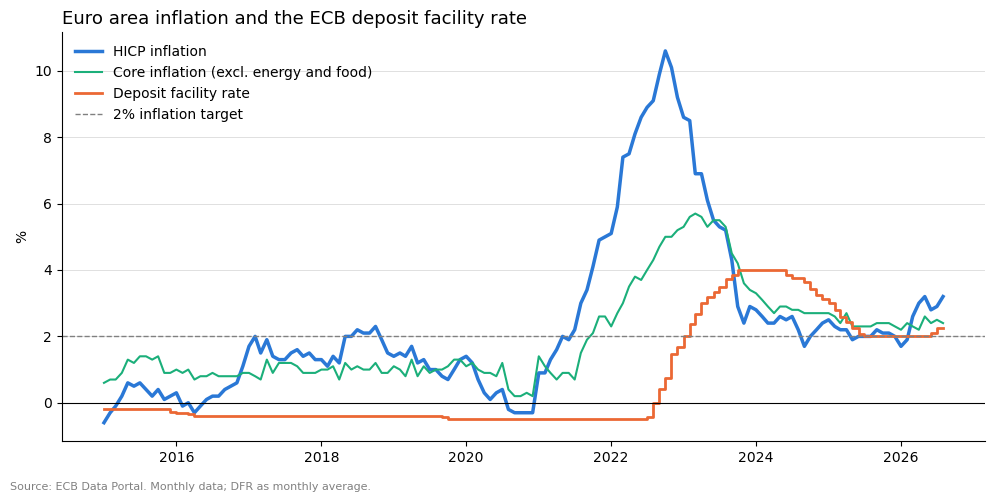

In [9]:
import matplotlib.pyplot as plt

# Colours: one per series, clearly distinct (also for colour-blind readers)
COLORS = {"HICP": "#2a78d6", "CORE": "#1baf7a", "DFR": "#eb6834"}

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Inflation: headline (main line, thicker) and core
ax.plot(monthly.index, monthly["HICP"], label="HICP inflation",
        color=COLORS["HICP"], linewidth=2.5)
ax.plot(monthly.index, monthly["CORE"], label="Core inflation (excl. energy and food)",
        color=COLORS["CORE"], linewidth=1.5)

# 2. DFR as a step line: it jumps on decision dates, it does not move gradually
ax.plot(monthly.index, monthly["DFR"], label="Deposit facility rate",
        color=COLORS["DFR"], linewidth=2, drawstyle="steps-post")

# 3. The 2% inflation target as a dashed horizontal line
ax.axhline(2, linestyle="--", color="grey", linewidth=1, label="2% inflation target")

# 4. Labels and legend
ax.set_title("Euro area inflation and the ECB deposit facility rate", loc="left", fontsize=13)
ax.set_ylabel("%")
ax.legend(frameon=False, loc="upper left")

# 5. Clean look: no top/right borders, light horizontal grid only
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)

# 6. Source note at the bottom
fig.text(0.01, 0.01, "Source: ECB Data Portal. Monthly data; DFR as monthly average.",
         fontsize=8, color="grey")

fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("figures/rates_inflation.png", dpi=200, bbox_inches="tight")
plt.show()

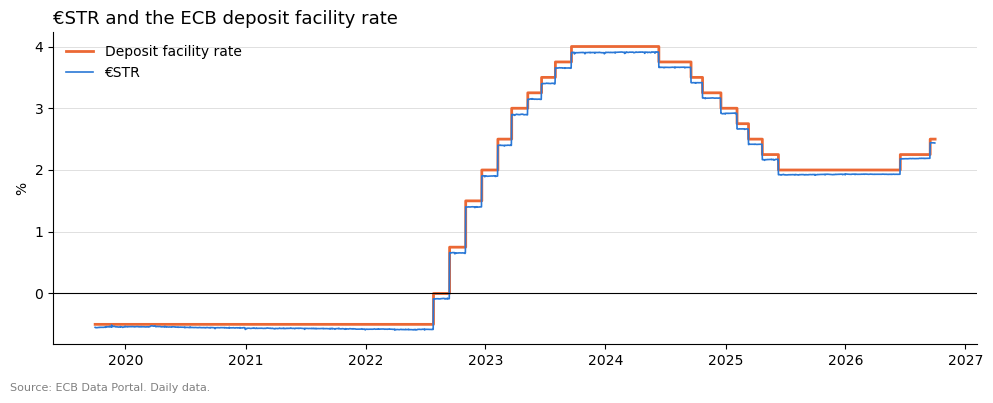

In [10]:
# Daily data from the start of the €STR (October 2019)
estr = data["ESTR"].loc["2019-10-01":]
dfr = data["DFR"].loc["2019-10-01":]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(dfr.index, dfr, label="Deposit facility rate",
        color=COLORS["DFR"], linewidth=2, drawstyle="steps-post")
ax.plot(estr.index, estr, label="€STR",
        color=COLORS["HICP"], linewidth=1.2)

ax.set_title("€STR and the ECB deposit facility rate", loc="left", fontsize=13)
ax.set_ylabel("%")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)

fig.text(0.01, 0.01, "Source: ECB Data Portal. Daily data.", fontsize=8, color="grey")

fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("figures/estr_dfr.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Analysis

In [11]:
# 1. First month with inflation above 2% after 2020
after_2020 = monthly.loc["2021-01-01":]
first_above_2 = after_2020[after_2020["HICP"] > 2].index[0]

# 2. First DFR hike after 2020
hikes = changes[changes > 0]
first_hike = hikes.loc["2021-01-01":].index[0]

# 3. Inflation peak (month and value)
peak_hicp_date = monthly["HICP"].idxmax()
peak_hicp = monthly["HICP"].max()

# 4. DFR peak (value and first day it was reached)
dfr = data["DFR"]
peak_dfr = dfr.max()
peak_dfr_date = dfr[dfr == peak_dfr].index[0]

# 5. First cut after the DFR peak
cuts = changes[changes < 0]
first_cut = cuts.loc[peak_dfr_date:].index[0]

print("Inflation first above 2%:", first_above_2.strftime("%B %Y"))
print("First DFR hike:          ", first_hike.date())
print(f"Inflation peak:           {peak_hicp:.1f}% in {peak_hicp_date.strftime('%B %Y')}")
print(f"DFR peak:                 {peak_dfr:.2f}% from {peak_dfr_date.date()}")
print("First cut after the peak:", first_cut.date())

Inflation first above 2%: July 2021
First DFR hike:           2022-07-27
Inflation peak:           10.6% in October 2022
DFR peak:                 4.00% from 2023-09-20
First cut after the peak: 2024-06-12


In [12]:
def months_between(start, end):
    "Number of calendar months between two dates."
    return (end.to_period("M") - start.to_period("M")).n

lag_first_hike = months_between(first_above_2, first_hike)
lag_peaks = months_between(peak_hicp_date, peak_dfr_date)

print("Months from inflation above 2% to first hike:", lag_first_hike)
print("Months from inflation peak to DFR peak:      ", lag_peaks)

Months from inflation above 2% to first hike: 12
Months from inflation peak to DFR peak:       11


Lowest real rate: -9.8% in October 2022
Real rate positive again: October 2023


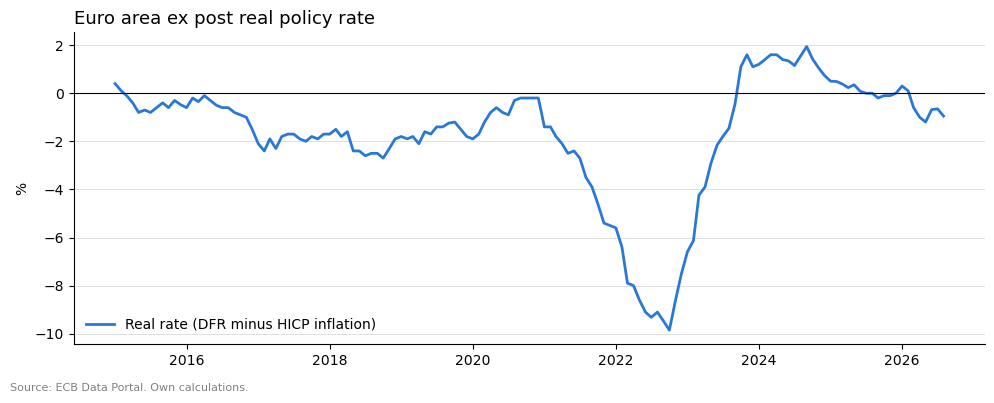

In [13]:
# Ex post real rate: policy rate minus current inflation
monthly["REAL"] = monthly["DFR"] - monthly["HICP"]

min_real = monthly["REAL"].min()
min_real_date = monthly["REAL"].idxmin()

# First month after the minimum when the real rate turns positive
after_min = monthly.loc[min_real_date:]
positive = after_min[after_min["REAL"] > 0]
# If it has not turned positive yet, keep None instead of raising an error.
if len(positive) > 0:
    first_positive = positive.index[0]
else:
    first_positive = None

print(f"Lowest real rate: {min_real:.1f}% in {min_real_date.strftime('%B %Y')}")
print("Real rate positive again:", first_positive.strftime("%B %Y") if first_positive is not None else "not yet")

# Chart
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["REAL"], color=COLORS["HICP"], linewidth=2,
        label="Real rate (DFR minus HICP inflation)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Euro area ex post real policy rate", loc="left", fontsize=13)
ax.set_ylabel("%")
ax.legend(frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
fig.text(0.01, 0.01, "Source: ECB Data Portal. Own calculations.", fontsize=8, color="grey")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("figures/real_rate.png", dpi=200, bbox_inches="tight")
plt.show()

Average €STR − DFR spread since 2023: -8.5 bp


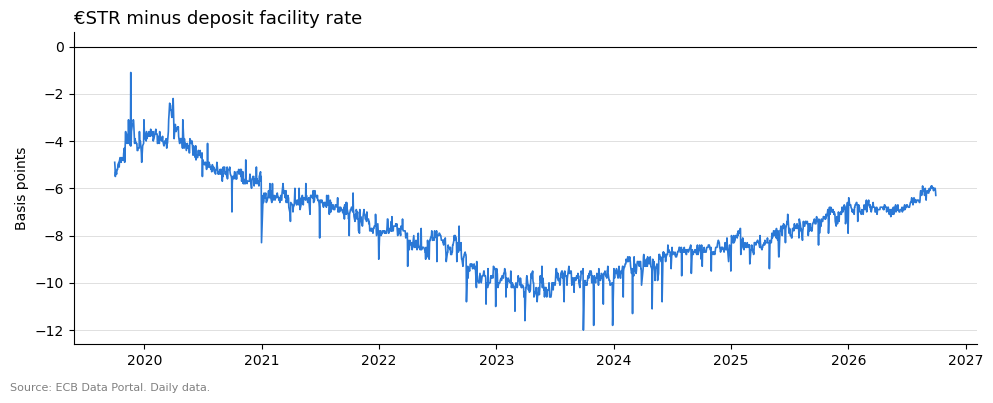

In [14]:
# Spread in basis points (1 percentage point = 100 bp)
spread = ((data["ESTR"] - data["DFR"]) * 100).dropna()
avg_spread_2023 = spread.loc["2023-01-01":].mean()

print(f"Average €STR − DFR spread since 2023: {avg_spread_2023:.1f} bp")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(spread.index, spread, color=COLORS["HICP"], linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("€STR minus deposit facility rate", loc="left", fontsize=13)
ax.set_ylabel("Basis points")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="lightgrey", linewidth=0.5)
fig.text(0.01, 0.01, "Source: ECB Data Portal. Daily data.", fontsize=8, color="grey")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("figures/estr_dfr_spread.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
rows = [
    ("Inflation first above 2%", first_above_2.strftime("%B %Y")),
    ("First DFR hike", str(first_hike.date())),
    ("Months from inflation above 2% to first hike", lag_first_hike),
    ("Peak HICP inflation", f"{peak_hicp:.1f}% ({peak_hicp_date.strftime('%B %Y')})"),
    ("Peak DFR", f"{peak_dfr:.2f}% (from {peak_dfr_date.date()})"),
    ("Months from inflation peak to DFR peak", lag_peaks),
    ("First cut after the peak", str(first_cut.date())),
    ("Lowest real rate", f"{min_real:.1f}% ({min_real_date.strftime('%B %Y')})"),
    ("Average €STR − DFR spread since 2023", f"{avg_spread_2023:.1f} bp"),
]

summary = pd.DataFrame(rows, columns=["Metric", "Value"])
summary

,Metric,Value
0,Inflation first above 2%,July 2021
1,First DFR hike,2022-07-27
2,Months from inflation above 2% to first hike,12
3,Peak HICP inflation,10.6% (October 2022)
4,Peak DFR,4.00% (from 2023-09-20)
5,Months from inflation peak to DFR peak,11
6,First cut after the peak,2024-06-12
7,Lowest real rate,-9.8% (October 2022)
8,Average €STR − DFR spread since 2023,-8.5 bp


## 5. Discussion

### Monetary policy stance through the real rate

In 2022, monetary policy remained clearly expansionary in real terms, even though the ECB had started raising rates. Inflation rose much faster than the policy rate, so the ex post real rate fell to around −9.8% in October 2022. Raising the DFR from −0.50% was not enough to offset inflation above 10%. By the end of 2023 the situation had reversed: with the DFR at 4.00% and inflation falling towards 2.9%, the real rate turned positive in October 2023 and peaked close to 2% in 2024, which points to a restrictive stance. Strictly speaking, policy is restrictive when the real rate is above the neutral real rate (r*), usually estimated to be close to zero for the euro area. In 2026, inflation picked up again to 3.2% and the real rate turned negative once more, despite two 25 bp hikes in June and September 2026.

### The €STR–DFR spread

Since the financial crisis, and especially after the asset purchase programmes, the euro area banking system has had large excess liquidity. In this "floor system", the DFR acts as the floor for overnight rates: banks can always deposit their spare liquidity at the ECB and earn the DFR, so they have no reason to lend for less. However, the €STR also includes transactions with counterparties that do not have access to the deposit facility, such as money market funds or other non-bank institutions. These lenders accept a rate slightly below the DFR, and banks borrow from them and deposit the funds at the ECB, earning the difference. The spread widened to around −10 bp in 2023 and has since narrowed to around −6 bp in 2026, as excess liquidity declines with the run-off of the ECB's balance sheet (-8.5 bp on average since 2023).

### Limitations of the ex post real rate

The relevant real rate for economic decisions is the ex ante real rate, defined as the nominal rate minus expected inflation, as in the Fisher equation. Using current inflation is a backward-looking approximation: during the 2022 surge, inflation was driven largely by energy prices, which were expected to be partly temporary, so the ex post measure probably overstates how expansionary policy actually was. A better approach would use inflation expectations, such as the ECB Survey of Professional Forecasters or market-based measures like inflation swaps. In addition, the DFR is an overnight rate, while households and firms borrow at longer maturities, so the real rate along the yield curve may tell a different story.